In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from torch.amp import autocast
from sklearn.decomposition import PCA
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

# Define the VAE model
class VAE(nn.Module):
    def __init__(self, z_dim=48, pose_dim=345):
        super(VAE, self).__init__()
        self.z_dim = z_dim

        # Encoder network
        self.fc1 = nn.Linear(pose_dim, 128)
        self.dropout = nn.Dropout(0.2)  # Dropout layer
        self.fc2_mu = nn.Linear(128, z_dim)  # Mean of latent space
        self.fc2_logvar = nn.Linear(128, z_dim)  # Log variance of latent space

        # Decoder network
        self.fc3 = nn.Linear(z_dim, 128)
        self.fc4 = nn.Linear(128, pose_dim)

    def encode(self, x):
        h1 = torch.relu(self.fc1(x))
        # h1 = self.dropout(h1)  # Apply dropout
        mu = self.fc2_mu(h1)
        logvar = self.fc2_logvar(h1)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h3 = torch.relu(self.fc3(z))
        # h3 = self.dropout(h3)  # Apply dropout
        # x_reconstructed = torch.sigmoid(self.fc4(h3))
        return self.fc4(h3)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_reconstructed = self.decode(z)
        return x_reconstructed, mu, logvar, z

# Loss function: VAE Loss = Reconstruction Loss + KL Divergence
def vae_loss(x_reconstructed, x, mu, logvar, bone_weights=None, beta=0.5, free_bits=0.5):
    pose_dim = x.size(-1)
    z_dim = mu.size(-1)
    batch_size = mu.size(0)
    # reconstruction_loss = nn.functional.mse_loss(x_reconstructed, x, reduction='sum')

    # Use the casted target for all loss calculations
    reconstruction_loss = nn.HuberLoss(reduction="none")(x_reconstructed, x)

    # Applying the bone category weighting
    if bone_weights is not None:
        reconstruction_loss = reconstruction_loss * bone_weights
    # print(f"reconstruction_loss shape after weighting: {reconstruction_loss.shape}")

    # # Now we find the mean
    reconstruction_loss = reconstruction_loss.sum(dim=1).mean()
    # print(f"Loss shape after meaning: {reconstruction_loss.shape}")



    # KL Divergence between the learned distribution and the prior (Gaussian)
    # D_KL(q(z|x) || p(z)) = -0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    # where mu, sigma are the mean and log-variance output by the encoder
    # and the prior is a standard normal distribution (mu=0, sigma=1)
    # The KL divergence measures how much our learned distribution differs from the prior
    # We want to minimize this difference, so the encoder outputs z's close to standard normal distribution.
    # A small KL divergence leads to better generalization.

    # Calculate the KL divergence
    # KL(q(z|x) || p(z)) = -0.5 * sum(1 + logvar - mu^2 - exp(logvar))
    
    # print("reconstion loss magnitude: ", reconstruction_loss.item())
    # KL = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp()).sum(dim=1).mean()

    # Per-dimension KL
    kl_per_dim = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp())  # shape: (batch, latent_dim)

    # Free bits threshold: allow minimum KL per dimension (in nats)
    kl_per_dim = torch.clamp(kl_per_dim, min=free_bits)

    # Mean over batch, sum over dimensions
    kl_divergence = kl_per_dim.mean(dim=0).sum()

    # print("KL loss magnitude: ", KL.item())
    return reconstruction_loss + beta * kl_divergence, reconstruction_loss, kl_divergence, kl_per_dim

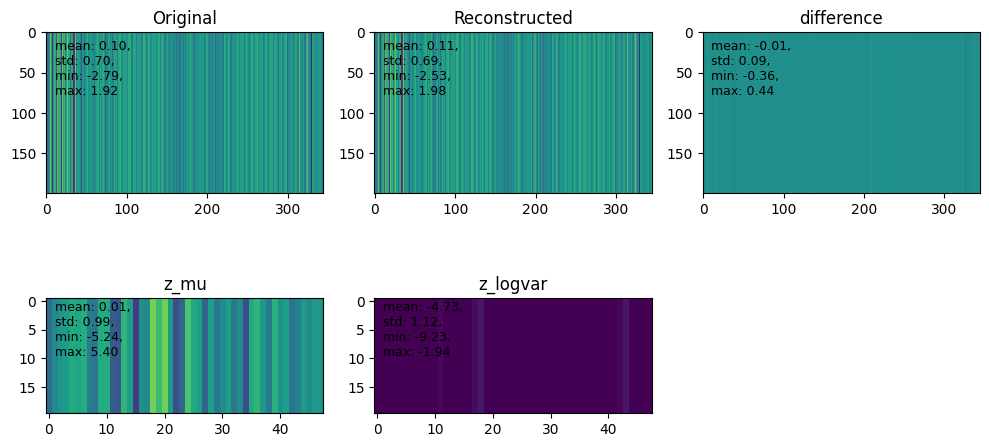

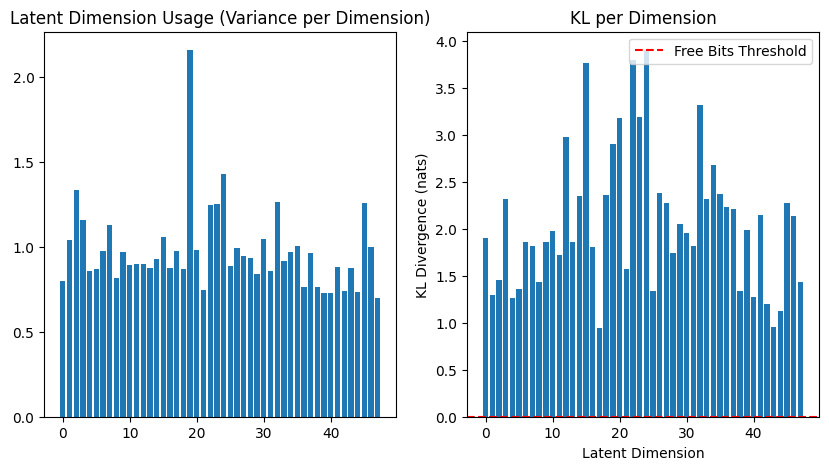

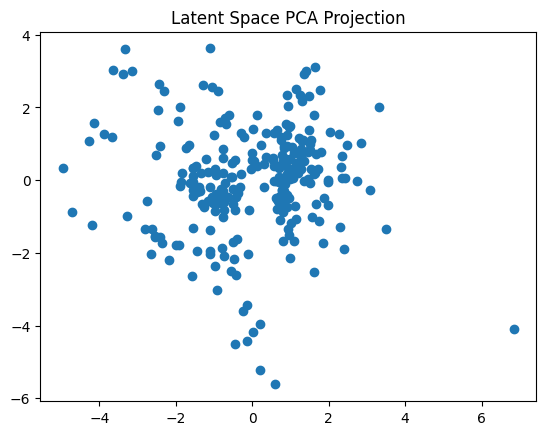

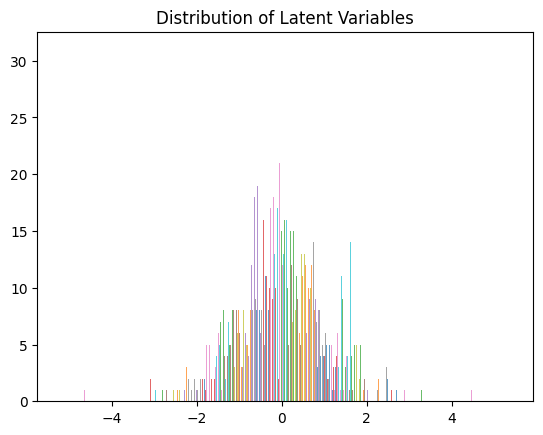

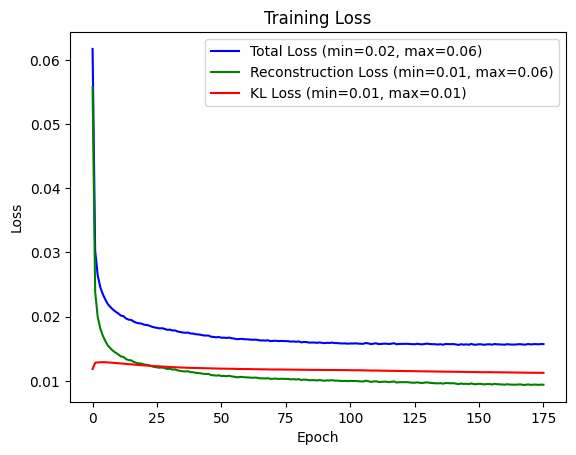

Active dimensions: 48/48
Epoch 176/200
Train Loss: 0.0157
Reconstruction Loss: 0.0094
KL Loss: 0.0113
Used KL weight: 0.0001
KL Weight: 0.0001, Reconstruction Loss: 0.0093, Ratio: 0.0060
Reshuffled dataset with new random windows
Reshuffled dataset with new random windows
Reshuffled dataset with new random windows
Reshuffled dataset with new random windows
Reshuffled dataset with new random windows
Reshuffled dataset with new random windows
Reshuffled dataset with new random windows
Reshuffled dataset with new random windows
Reshuffled dataset with new random windows
Reshuffled dataset with new random windows
Reshuffled dataset with new random windows
Reshuffled dataset with new random windows
Reshuffled dataset with new random windows
Reshuffled dataset with new random windows
Reshuffled dataset with new random windows
Reshuffled dataset with new random windows
Reshuffled dataset with new random windows
Reshuffled dataset with new random windows
Reshuffled dataset with new random wind

In [2]:
from dataset.dataset import *
from IPython.display import clear_output
from sklearn.decomposition import PCA

pose_training_loader=DataLoader(
    GPUDataset(
        consolidated_file= "dataset/genea2023_dataset/trn/main-agent/consolidated.npz", # or "dataset/genea2023_dataset/trn/main-agent/training_windows_100k.npz"
        seq_length=1,
        seed_length=0,
        batch_size=256,
        epoch_length=512,
        device=device
    ),
    batch_size = 1,
    num_workers = 0,
    pin_memory = False
)
# Create the model, optimizer, and loss function
model = VAE()
model.to(device)

# Skeleton data used to weight bones differently in the loss function
# Initialize a tensor of zeros with the same length as the number of bones
category_weighting = {
    'fingers': 0.2,
    'arms': 2.0,
    'legs': 1.0,
    'spine': 2.0,
    'head': 1.0,
    'root': 2.0
}

# Skeleton data used to weight bones differently in the loss function.
# Initialize a tensor of zeros with the same length as the number of bones
skeleton = pose_training_loader.dataset.skeleton
num_features = skeleton.get_channel_count()
bone_index_weighted_by_category_vector = torch.ones(num_features)
bone_index_weighted_by_category_vector = bone_index_weighted_by_category_vector.to(device)

# Assign weights based on the categories
for category, weight in category_weighting.items():
    # Check if the category exists in the skeleton info
    if skeleton.bone_categories is None or category not in skeleton.bone_categories:
        print(f"Warning: Category '{category}' not found in skeleton info. Skipping.")
        continue
    for bone_name in skeleton.bone_categories[category]:
        bone_indices = skeleton.bone_to_indices_map[bone_name]
        # Check if bone exists in the skeleton info
        if bone_indices is None:
            print(f"Warning: Bone '{bone_name}' not found in skeleton info. Skipping.")
            continue
        for index in bone_indices:
            bone_index_weighted_by_category_vector[index] = weight

# Normalize the weights to sum to 1. This is to prevent the loss from being too large or too small compared to the KL divergence term
bone_index_weighted_by_category_vector /= bone_index_weighted_by_category_vector.sum()

losses = []
reconstruction_losses = []
kl_losses = []
kl_per_dim_last_epoch = None


# Training loop
optimizer = optim.Adam(model.parameters(), lr=3e-3)
num_epochs = 200
warm_up_kl_anneal_steps = 100 # number of epochs before KL annealing starts
kl_anneal_steps = 300
free_bits = 0.0  # Free bits threshold for KL divergence
kl_beta=0.0001

visualize_steps = 25 # Number of steps to visualize the training process

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    train_reconstruction_loss = 0
    train_kl_loss = 0

    pose_training_loader.dataset.reshuffle()

    for batch_idx, batch_data in enumerate(pose_training_loader):

        pose, _, _, _ = [
            item.squeeze(0).squeeze(1).to(device) for item in batch_data
        ]
        
        # pose to float # TODO: Probably dont do this
        pose = pose.float()

        optimizer.zero_grad()
        # Forward pass
        x_reconstructed, mu, logvar, z = model(pose)
        
        kl_weight = kl_beta * torch.sigmoid(
            torch.tensor(min(1.0, max(0.0, (epoch - warm_up_kl_anneal_steps) / kl_anneal_steps)))
        )


        # Compute loss
        loss, reconstruction_loss, kl_loss, kl_per_dim = vae_loss(x_reconstructed, pose, mu, logvar, bone_index_weighted_by_category_vector, beta=kl_weight, free_bits=free_bits)
        # loss, reconstruction_loss, kl_loss, total_correlation, kl_per_dim = tc_vae_loss(x_reconstructed, pose, mu, logvar, z, beta=0.001, beta_tc=5.0, beta_kl=0.1, beta_mi=0.5, bone_weights=bone_index_weighted_by_category_vector)
        kl_per_dim_last_epoch = kl_per_dim
        loss.backward()
        
        # Update weights
        optimizer.step()
        train_loss += loss.item()
        train_reconstruction_loss += reconstruction_loss.item()
        train_kl_loss += kl_loss.item() * kl_beta
    
    losses.append(train_loss / len(pose_training_loader.dataset))
    reconstruction_losses.append(train_reconstruction_loss / len(pose_training_loader.dataset))
    kl_losses.append(train_kl_loss / len(pose_training_loader.dataset))
    
    if epoch % visualize_steps == 0:


        with torch.no_grad():
            clear_output(wait=True)
            plt.figure(figsize=(10, 5))
            plt.subplot(2, 3, 1)
            plt.title("Original")
            plt.text(10, 45, f"mean: {pose[0].mean().item():.2f}, \nstd: {pose[0].std().item():.2f}, \nmin: {pose[0].min().item():.2f}, \nmax: {pose[0].max().item():.2f}", fontsize=9, ha='left', va='center')
            plt.imshow(pose[0].repeat(200,1).cpu().detach().numpy(), cmap='viridis', vmin=-3, vmax=3)
            
            plt.subplot(2, 3, 2)
            plt.title("Reconstructed")
            plt.text(10, 45, f"mean: {x_reconstructed[0].mean().item():.2f}, \nstd: {x_reconstructed[0].std().item():.2f}, \nmin: {x_reconstructed[0].min().item():.2f}, \nmax: {x_reconstructed[0].max().item():.2f}", fontsize=9, ha='left', va='center')
            plt.imshow(x_reconstructed[0].repeat(200,1).cpu().detach().numpy(), cmap='viridis', vmin=-3, vmax=3)

            difference = pose[0] - x_reconstructed[0]
            plt.subplot(2, 3, 3)
            plt.title("difference")
            plt.text(10, 45, f"mean: {difference.mean().item():.2f}, \nstd: {difference.std().item():.2f}, \nmin: {difference.min().item():.2f}, \nmax: {difference.max().item():.2f}", fontsize=9, ha='left', va='center')
            plt.imshow((difference).repeat(200,1).cpu().detach().numpy(), cmap='viridis', vmin=-3, vmax=3)

            plt.subplot(2, 3, 4)
            plt.title("z_mu")
            plt.text(1, 5, f"mean: {mu.mean().item():.2f}, \nstd: {mu.std().item():.2f}, \nmin: {mu.min().item():.2f}, \nmax: {mu.max().item():.2f}", fontsize=9, ha='left', va='center')
            plt.imshow(mu[0].repeat(20,1).cpu().detach().numpy(), cmap='viridis', vmin=-3, vmax=3)

            plt.subplot(2, 3, 5)
            plt.title("z_logvar")
            plt.text(1, 5, f"mean: {logvar.mean().item():.2f}, \nstd: {logvar.std().item():.2f}, \nmin: {logvar.min().item():.2f}, \nmax: {logvar.max().item():.2f}", fontsize=9, ha='left', va='center')
            plt.imshow(logvar[0].repeat(20,1).cpu().detach().numpy(), cmap='viridis', vmin=-3, vmax=3)
            plt.tight_layout()
            plt.show()

            plt.figure(figsize=(10, 5))
            mu_var = mu.var(dim=0).cpu().numpy()
            plt.subplot(1, 2, 1)
            plt.title("Latent Dimension Usage (Variance per Dimension)")
            plt.bar(range(len(mu_var)), mu_var)

            kl_per_dim_last_epoch = kl_per_dim_last_epoch[0].cpu().numpy()
            plt.subplot(1, 2, 2)
            plt.bar(range(len(kl_per_dim_last_epoch)), kl_per_dim_last_epoch)
            plt.xlabel("Latent Dimension")
            plt.ylabel("KL Divergence (nats)")
            plt.title("KL per Dimension")
            plt.axhline(y=free_bits, color='r', linestyle='--', label='Free Bits Threshold')
            plt.legend()
            plt.show()

            latent_samples = model.reparameterize(mu, logvar)

            pca = PCA(n_components=2)
            latent_2d = pca.fit_transform(latent_samples.cpu().numpy())
            plt.scatter(latent_2d[:, 0], latent_2d[:, 1])
            plt.title('Latent Space PCA Projection')
            plt.show()

            # After obtaining latent variables (mu or z)
            plt.hist(mu.detach().cpu().numpy(), bins=100, alpha=0.7)
            plt.title('Distribution of Latent Variables')
            plt.show()

        def normalize_list(data_list):
            epsilon = 1e-8  # Small constant to prevent division by zero
            min_val = min(data_list)
            max_val = max(data_list)
            return [(x - min_val) / (max_val - min_val + epsilon) for x in data_list]

        # normalized_losses = normalize_list(losses)
        # normalized_reconstruction_losses = normalize_list(reconstruction_losses)
        # normalized_kl_losses = normalize_list(kl_losses)

        # Draw the training loss
        plt.plot(losses, label=f"Total Loss (min={min(losses):.2f}, max={max(losses):.2f})", color="blue")
        plt.plot(reconstruction_losses, label=f"Reconstruction Loss (min={min(reconstruction_losses):.2f}, max={max(reconstruction_losses):.2f})", color="green")
        plt.plot(kl_losses, label=f"KL Loss (min={min(kl_losses):.2f}, max={max(kl_losses):.2f})", color="red")
        plt.title("Training Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.show()

        active_dims = (kl_per_dim_last_epoch > 0.01).sum()
        print(f"Active dimensions: {active_dims}/{model.z_dim}")

        # As an example, print the value of the 50th pixel for both the original and reconstructed images
        print(f"Epoch {epoch + 1}/{num_epochs}")
        print(f"Train Loss: {train_loss / len(pose_training_loader.dataset):.4f}")
        print(f"Reconstruction Loss: {train_reconstruction_loss / len(pose_training_loader.dataset):.4f}")
        print(f"KL Loss: {train_kl_loss / len(pose_training_loader.dataset):.4f}")
        print(f"Used KL weight: {kl_weight:.4f}")

        recon = reconstruction_loss.item()
        ratio = kl_weight / recon
        print(f"KL Weight: {kl_weight:.4f}, Reconstruction Loss: {recon:.4f}, Ratio: {ratio:.4f}")

        
# Saving the trained model
torch.save(model.state_dict(), "vae_beta_0.1.pth")

In [3]:
# Load the model for inference
model = VAE()
model.to(device)
model.load_state_dict(torch.load("vae_beta_15-05-2025-trn-dataset-48-dim.pth"))

FileNotFoundError: [Errno 2] No such file or directory: 'vae_beta_15-05-2025-trn-dataset-48-dim.pth'

In [ ]:
# Import the viewer
import animation_visualisation
animation_visualisation.init_visualization()

HTTP Server running on http://localhost:8000
WebSocket server running on ws://localhost:8700


Animation viewer ready!
HTTP Server: http://localhost:8000/bvh_tests/bvh_visualisation/bvh_viewer_5.html?wsport=8700
WebSocket Server: ws://localhost:8700
Remember to click 'Start Streaming' button in the viewer.


8700

WebSocket client connected. Total connections: 1


In [ ]:
import time
import numpy as np
from utils.bvh_processing.bvh_converter import BVHParser
from IPython.display import clear_output


# Load std_pose and mean_pose from statistics.npz
statistics = np.load("dataset/genea2023_dataset/trn/main-agent/statistics.npz")
mean_pose = torch.tensor(statistics['mean_pose'].astype(np.float32)).to(device)
std_pose = torch.tensor(statistics['std_pose'].astype(np.float32)).to(device)

target_joints = ['body_world', 'b_root', 'b_r_foot', 'b_l_foot', 'b_l_upleg', 'b_l_leg', 'b_r_upleg', 'b_r_leg', 
                'b_spine0', 'b_spine1', 'b_spine2', 'b_spine3', 'b_l_shoulder', 'b_l_arm', 'b_l_arm_twist', 
                'b_l_forearm', 'b_l_wrist_twist', 'b_l_wrist', 'b_l_pinky1', 'b_l_pinky2', 'b_l_pinky3', 'b_l_ring1', 
                'b_l_ring2', 'b_l_ring3', 'b_l_middle1', 'b_l_middle2', 'b_l_middle3', 'b_l_index1', 'b_l_index2', 
                'b_l_index3', 'b_l_thumb0', 'b_l_thumb1', 'b_l_thumb2', 'b_l_thumb3', 'b_r_shoulder', 'b_r_arm', 
                'b_r_arm_twist', 'b_r_forearm', 'b_r_wrist_twist', 'b_r_wrist', 'b_r_thumb0', 'b_r_thumb1', 
                'b_r_thumb2', 'b_r_thumb3', 'b_r_pinky1', 'b_r_pinky2', 'b_r_pinky3', 'b_r_middle1', 'b_r_middle2', 
                'b_r_middle3', 'b_r_ring1', 'b_r_ring2', 'b_r_ring3', 'b_r_index1', 'b_r_index2', 'b_r_index3', 
                'b_neck0', 'b_head']

bvh_template = "bvh_tests/bvh/template.bvh"

# Load the BVH file and extract features
parser = BVHParser(bvh_template, target_joints)


with torch.no_grad():

    # Generate two random poses and interpolate between them
    sample1 = torch.randn(1, 48).to(device)  # Sample random z-values
    pose1 = model.decode(sample1)


    # Get the first 64 samples from the dataset
    for i in range(64):
        
        sample2 = torch.randn(1, 48).to(device)  # Sample random z-values
        pose2 = model.decode(sample2)

        for alpha in torch.linspace(0, 1, 40):
            # Interpolate between the two poses
            x_reconstructed = (1 - alpha) * pose1 + alpha * pose2

            # unormalize the reconstructed pose
            x_reconstructed_unnormalized = x_reconstructed * std_pose + mean_pose

            # Send the reconstructed pose to the viewer
            reconstructed_frame = parser.skeleton.features_to_websocket_format(x_reconstructed_unnormalized.unsqueeze(0).cpu(),frame_idx=0)
            animation_visualisation.send_frame(reconstructed_frame)
        animation_visualisation.send_frame(reconstructed_frame)

        print("Reconstructed pose sent to viewer")

        pose1 = pose2

        # wait for 3 seconds
        # time.sleep(1)


Reconstructed pose sent to viewer
Reconstructed pose sent to viewer
Reconstructed pose sent to viewer
Reconstructed pose sent to viewer
Reconstructed pose sent to viewer
Reconstructed pose sent to viewer
Reconstructed pose sent to viewer
Reconstructed pose sent to viewer
Reconstructed pose sent to viewer
Reconstructed pose sent to viewer
Reconstructed pose sent to viewer
Reconstructed pose sent to viewer
Reconstructed pose sent to viewer
Reconstructed pose sent to viewer
Reconstructed pose sent to viewer
Reconstructed pose sent to viewer
Reconstructed pose sent to viewer
Reconstructed pose sent to viewer
Reconstructed pose sent to viewer
Reconstructed pose sent to viewer
Reconstructed pose sent to viewer
Reconstructed pose sent to viewer
Reconstructed pose sent to viewer
Reconstructed pose sent to viewer
Reconstructed pose sent to viewer
Reconstructed pose sent to viewer
Reconstructed pose sent to viewer
Reconstructed pose sent to viewer
Reconstructed pose sent to viewer
Reconstructed 

KeyboardInterrupt: 

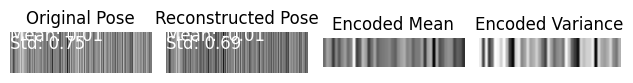

Original pose sent to viewer
Reconstructed pose sent to viewer


KeyboardInterrupt: 

In [ ]:
import time
from utils.bvh_processing.bvh_converter import BVHParser
from IPython.display import clear_output
from utils.bvh_processing.skeleton import Skeleton

with torch.no_grad():

    # Load the dataset
    dataset = GPUDataset(
        consolidated_file= "dataset/genea2023_dataset/toy/main-agent/consolidated.npz",
        seq_length=1,
        seed_length=0,
        batch_size=1,
        epoch_length=64
    )

    skeleton: Skeleton = dataset.skeleton

    skeleton.set_device(device)

    # Get the first 64 samples from the dataset
    for i in range(64):
        pose, _, _, _ = [
            item.squeeze(0) for item in dataset[i]
        ]

        # pose to float # TODO: Probably dont do this
        pose = pose.float()

        # pass the pose through the model
        # x_reconstructed, mu, logvar = model(pose)
        x_encoded_mean, x_encoded_var = model.encode(pose)
        x_reconstructed = model.decode(x_encoded_mean)

        # let x_reconsturcted instead be a fully original pose
        # sample = torch.randn(1, 32).to(device)  # Sample random z-values
        # x_reconstructed = model.decode(sample)

        # unormalize the reconstructed pose
        # x_reconstructed_unnormalized = x_reconstructed * std_pose + mean_pose
        x_reconstructed_unnormalized = skeleton.denormalize_poses(x_reconstructed)

        # unnormalize the original pose
        # pose_unnormalized = pose * std_pose + mean_pose
        pose_unnormalized = skeleton.denormalize_poses(pose)


        # Draw a picture of the original and reconstructed pose
        plt.subplot(1, 4, 1)
        plt.imshow(pose.repeat(100,1).cpu().numpy(),cmap='gray')
        plt.title("Original Pose")
        plt.axis('off')
        # Write the mean of the pose
        plt.text(0, 20, f"Mean: {pose.mean().item():.2f}", color='white', fontsize=12)
        # Write the std of the pose
        plt.text(0, 40, f"Std: {pose.std().item():.2f}", color='white', fontsize=12)

        plt.subplot(1, 4, 2)
        plt.imshow(x_reconstructed.repeat(100,1).cpu().numpy(),cmap='gray')
        plt.title("Reconstructed Pose")
        plt.axis('off')
        # Write the mean of the pose
        plt.text(0, 20, f"Mean: {x_reconstructed.mean().item():.2f}", color='white', fontsize=12)
        # Write the std of the pose
        plt.text(0, 40, f"Std: {x_reconstructed.std().item():.2f}", color='white', fontsize=12)

        # Draw the encoded mean and variance
        plt.subplot(1, 4, 3)
        plt.imshow(x_encoded_mean.repeat(10,1).cpu().numpy(),cmap='gray')
        plt.title("Encoded Mean")
        plt.axis('off')
        plt.subplot(1, 4, 4)
        plt.imshow(x_encoded_var.repeat(10,1).cpu().numpy(),cmap='gray')
        plt.title("Encoded Variance")
        plt.axis('off')
        plt.tight_layout()

        plt.show()


        # Send the original pose to the viewer
        original_frame = skeleton.features_to_websocket_format((pose_unnormalized).unsqueeze(0).cpu(),frame_idx=0)
        animation_visualisation.send_frame(original_frame)
        animation_visualisation.send_frame(original_frame)

        print("Original pose sent to viewer")

        # wait for 1 seconds
        time.sleep(0.5)

        # Send the reconstructed pose to the viewer
        reconstructed_frame = skeleton.features_to_websocket_format(x_reconstructed_unnormalized.unsqueeze(0).cpu(),frame_idx=0)
        animation_visualisation.send_frame(reconstructed_frame)
        animation_visualisation.send_frame(reconstructed_frame)

        print("Reconstructed pose sent to viewer")

        # wait for 3 seconds
        time.sleep(3)

        clear_output(wait=True)



Found 49628 valid starting points for windows
x shape: torch.Size([4096, 345])
Latent samples shape: torch.Size([4096, 32])


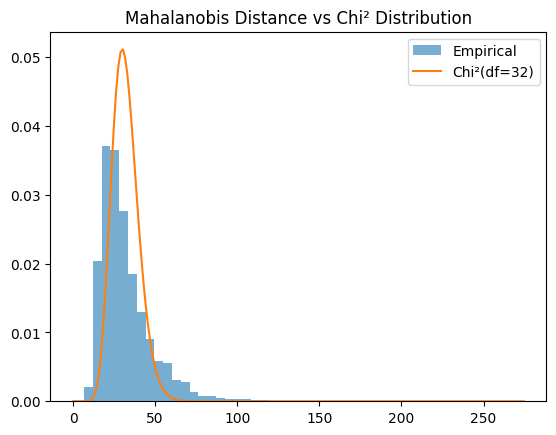

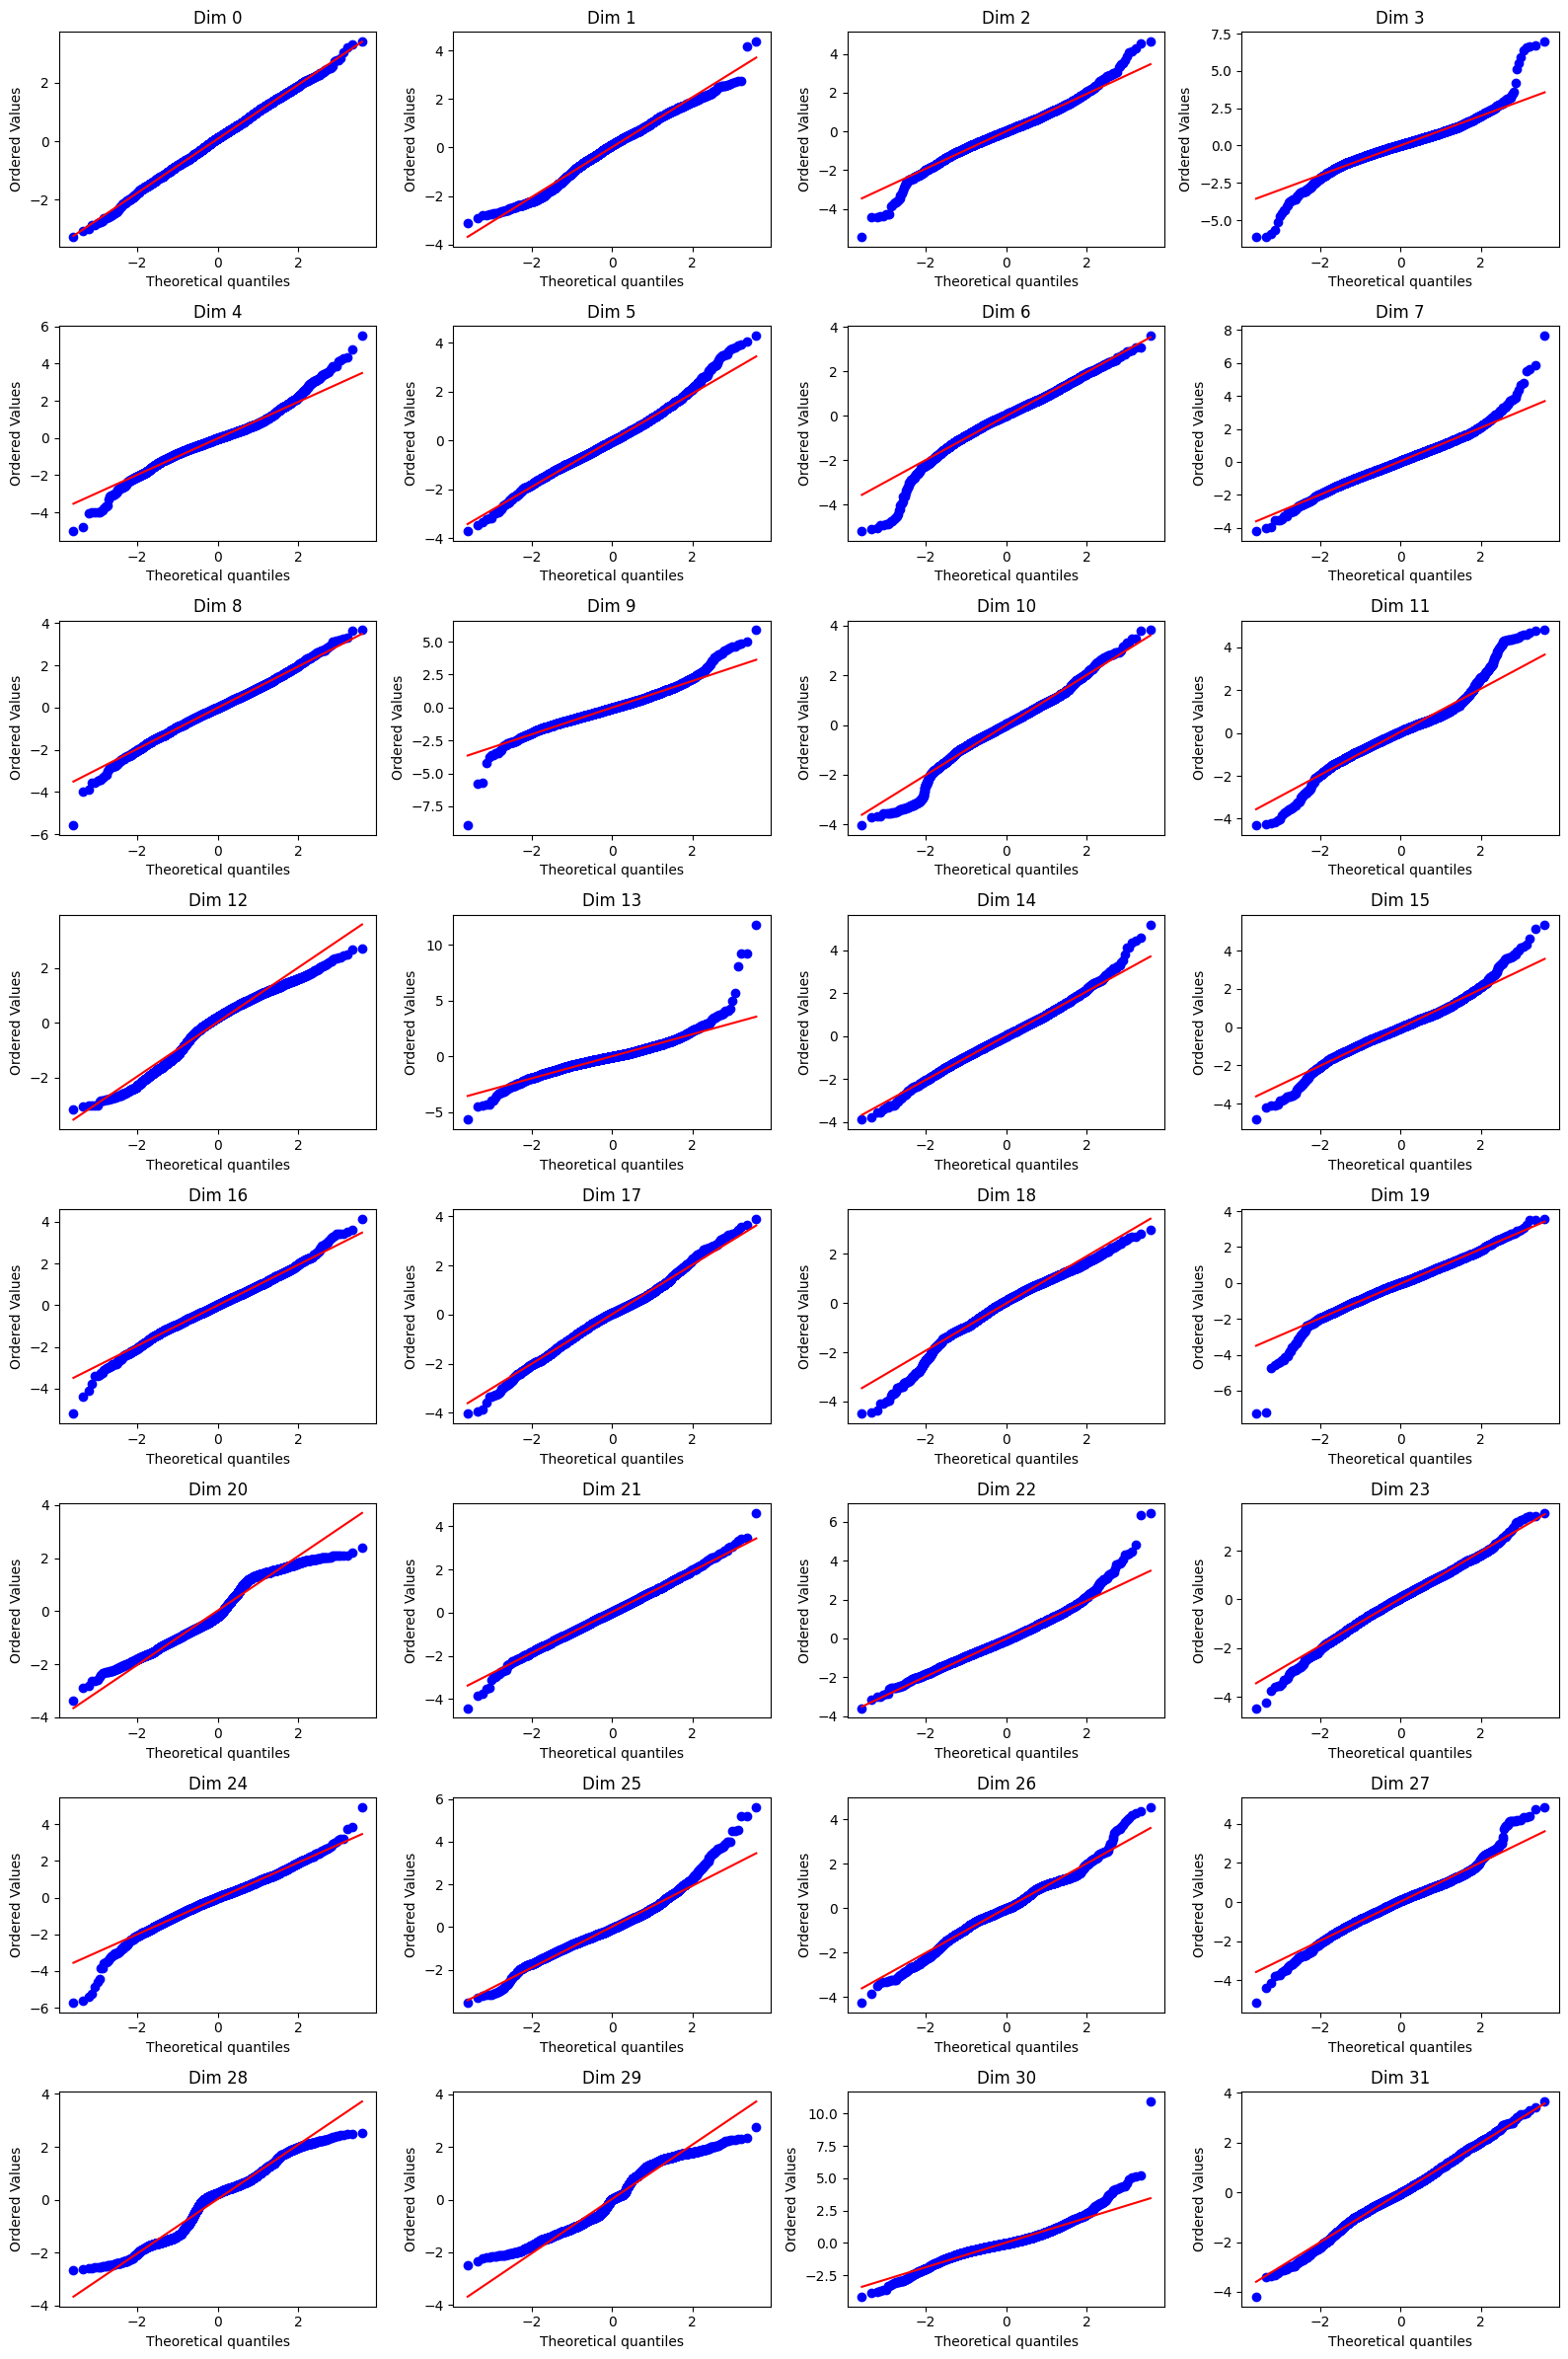

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

def mahalanobis_distance(z: torch.Tensor):
    # z: [N, D]
    mu = z.mean(dim=0)
    centered = z - mu
    cov = torch.cov(centered.T) + 1e-5 * torch.eye(z.size(1))
    inv_cov = torch.linalg.inv(cov)
    dists = torch.sum(centered @ inv_cov * centered, dim=1)
    return dists

# Load the dataset
dataset = ConsolidatedRAMDataset(
    consolidated_file= "dataset/genea2023_dataset/toy/main-agent/consolidated.npz",
    seq_length=1,
    seed_length=0,
    batch_size=1,
    epoch_length=4096
)

data_loader = DataLoader(dataset, batch_size=10000, shuffle=True)

all_latent_samples = []

# Example of generating latent samples
with torch.no_grad():  # No need to compute gradients for latent sampling
    for batch_idx, batch_data in enumerate(data_loader):

        x, _, _, _ = [
            item.squeeze(1).squeeze(1).float().to(device) for item in batch_data
        ]

        print(f"x shape: {x.shape}")
        
        x = x.to(device)  # Move data to device (GPU or CPU)
        mu, logvar = model.encode(x)  # Get mean and log-variance from the encoder
        latent_sample = model.reparameterize(mu, logvar)  # Generate latent sample
        all_latent_samples.append(latent_sample.cpu())  # Store latent samples (move to CPU if needed)

# Combine all latent samples into a single tensor
latent_samples = torch.cat(all_latent_samples, dim=0)  # Shape: [num_samples, z_dim]

print(f"Latent samples shape: {latent_samples.shape}")

# Example:
z = latent_samples.cpu().numpy()  # shape [N, D]
dists = mahalanobis_distance(latent_samples)

# Compare with chi-squared distribution
df = z.shape[1]
plt.hist(dists.numpy(), bins=50, density=True, alpha=0.6, label='Empirical')
x = np.linspace(0, np.max(dists.cpu().numpy()), 200)
plt.plot(x, chi2.pdf(x, df), label=f'Chi²(df={df})')
plt.title("Mahalanobis Distance vs Chi² Distribution")
plt.legend()
plt.show()

import scipy.stats as stats

def qq_plot(z: torch.Tensor):
    D = z.shape[1]
    fig, axs = plt.subplots(nrows=(D + 3) // 4, ncols=4, figsize=(16, 3 * ((D + 3) // 4)))
    axs = axs.flatten()
    for i in range(D):
        stats.probplot(z[:, i], dist="norm", plot=axs[i])
        axs[i].set_title(f'Dim {i}')
    plt.tight_layout()
    plt.show()

# Usage
qq_plot(z)